# A higher template-matching threshold, applied before NMS: what it does to the top-20

**The question.** Replicate `find_and_suppress` on the 14-ROI `images/extra_valid` set, one click
per ROI, raise the `TM_CCOEFF` score floor *before* the candidates reach NMS, and measure the
exact effect on **the number of true mitotic figures in the first 20 candidates** once the
survivors are ranked by match score. Report **precision**, not `recall@K`.

**The answer, stated first.** Raising the pre-NMS floor changes the top-20 by **exactly
nothing** until the floor is high enough to leave fewer than 20 candidates alive — and past
that point it can only *remove* true positives, never add one. Pooled over the 14 ROIs the
top-20 holds **127 / 280** true positives (**precision@20 = 0.4536**) at the deep floor, at the
current operating point `z = 1.0`, and at `z = 2, 3, 4, 5` — the same 127, cell by cell, not on
average. The first threshold that moves it is `z = 6`, where `245.tiff` stops being able to
return 20 candidates at all; from there it falls to 86 at `z = 8`, 35 at `z = 12` and 1 at
`z = 26`. **There is no threshold at which the top 20 gets better.**

**Why, in one paragraph.** Peak extraction applies the floor pixel-wise and NMS is greedy in
*descending* score order, so a candidate below the floor can never suppress one above it. The
retained list at a high floor is therefore an exact **prefix** of the retained list at a low
one — same points, same scores, same order. "Take the top 20 of the list that survives floor
`t`" and "take the top 20 of the full list" are the same 20 points for every `t` that leaves 20
points standing. **The threshold and `K` are the same knob in different units**, and `K` is the
one that binds first. This notebook does not assume that: it re-runs peak extraction and NMS
from scratch at every threshold and checks the two routes agree point-for-point (Gate 2).

**Where a higher threshold genuinely acts.** On the precision of the *whole retained list*,
which is what the threshold actually controls: 0.0065 at `z = 1.0` rising to 0.0481 at `z = 6`,
the highest global threshold at which all 14 ROIs still return something. It is bought entirely
by deletion — over that same range the number of mitoses found anywhere in the list falls from
1307 to 739, and `245.tiff` -- the worst ROI at every threshold in the grid -- goes from
97.8 % of its mitoses retained to 0 %. Push further and
the curve does climb to meet precision@20, but only in a region where 11 of 14 ROIs return an
empty list. Table 3 and Figure 2 show both halves of that.

**One trap in Table 1, flagged before it is read.** Pooled `precision@20` is *not* monotone: it
ticks **up** from 0.4536 to 0.4809 at `z = 6`. That is not an improvement. `245.tiff` is both
the worst ROI in the set (1 mitosis in its top 20, precision 0.05) and the first to be starved,
so at `z = 6` it contributes 2 candidates to the denominator instead of 20 and the pooled ratio
rises because the worst case has been *censored*, not fixed. The raw count `tp_at_20` — which
has no denominator to game — falls at that very step, 127 → 126. This is why both columns are
reported.

---

### Scope and configuration

| | |
|---|---|
| ROIs | `images/extra_valid` — 14, two per tumour type across all 7 domains (that folder's `MANIFEST.md`) |
| clicks | **1 per ROI**, `seed_index = 0`, drawn on the `np.random.default_rng([0, image_id])` stream — the same draw `recall_workload_ledger.py` and `tp_fp_feature_extract.py` make |
| channel / method | `hematoxylin_od`, `cv2.TM_CCOEFF` (`DECISIONS.md` D1) |
| template | **largest-CC tightening** — Otsu the 51 px click crop on `gray_inverted`, take the largest connected component, use `_odd(max side)` as `base_size` |
| augmentation | **none** — `scales=(1.0,)`, `n_angles=1`, `flips=(False,)` |
| NMS radius | **the default, 7.5 µm** = `evaluate.MIDOG_RADIUS_UM`, 29.6–33.1 px. This is `FSConfig(nms_radius=None)`'s documented meaning and the value `2026-09-04-f5-results.md` §7 recommends. A second 5.0 µm arm is run as the reproduction gate against the committed ledger, and Gate 4 shows the reported number is **the same at either radius** — so the ambiguity in "the default" does not reach the answer. |
| border | `BORDER_REPLICATE` padding by the template half-width, so the whole ROI is reachable (F6) |
| peak spacing | `peak_min_distance = 7`; self-hit dropped at 5 px |

**Thresholds are in robust-z units**, `cut = median + z · (1.4826 · MAD)` of that ROI's own
response map, via `template_match.robust_stats`. They have to be: `TM_CCOEFF` is unnormalised,
so its range depends on the template's and the image's contrast and a fixed raw floor means a
different search depth on every ROI (`DECISIONS.md` D1, *"What it costs"*). The raw floor each
`z` corresponds to is recorded per ROI as `score_cut` anyway.

**One caveat, stated up front.** One click per ROI is what was asked for, and it is one draw.
Prior runs on this same set measure roughly a 2× click-to-click spread in reading depth, so the
*per-ROI* numbers below carry click noise. The pooled result does not depend on it — the
invariance in Table 2 is exact per cell, not on average.

In [1]:
import gc
import time
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

sys.path.insert(0, '.')
from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 220)

NB_T0 = time.time()

# ---------------------------------------------------------------------------------------
# Configuration. Everything above the Z grid is copied from `recall_workload_ledger.py`
# rather than re-derived, so the run is gate-able against the committed artefact.
# ---------------------------------------------------------------------------------------
IMAGES_DIR = 'images/extra_valid'
SEED_INDEX = 0

CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
PEAK_MIN_DISTANCE = 7
SELF_HIT_RADIUS = 5.0
DEEP_FLOOR_Z = -1.5              # the reference pool; below every grid level
CURRENT_Z = 1.0                  # today's operating point
MAX_PEAKS = 2_000_000

NMS_RADIUS_UM = ev.MIDOG_RADIUS_UM   # 7.5 um -- the repo default (FSConfig.nms_radius=None)
GATE_RADIUS_UM = 5.0                 # the committed ledger's value; used ONLY by Gate 1
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM

CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2         # 36
OTSU_WINDOW = tm.BASE_SIZE           # 51
LARGEST_CC_KW = dict(min_area=50, max_area_frac=0.85, min_solidity=0.5)

# The thresholds under test. CURRENT_Z is the baseline; everything above it is "higher".
# The top of the grid is set by the data: the single best-scoring candidate in the whole
# 14-ROI set sits at z = 28.8 (403.tiff), so z = 26 is the last level that leaves anything
# alive anywhere, and z = 30 would be an all-empty row.
Z_GRID = (1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0, 15.0, 18.0, 22.0, 26.0)
Z_ALL = (DEEP_FLOOR_Z,) + Z_GRID     # deep floor first: it is the reference pool
K = 20                               # the budget the question is about

# Gate 2b traces NMS's suppression bookkeeping on one ROI. Its deep-floor peak arrays are
# stashed during the main run rather than recomputed -- 460.tiff has the smallest deep pool
# in the set, so the trace is the cheapest possible and still fully representative.
TRACE_ROI = '460.tiff'
TRACE = {}

OUT_CELLS = 'results/fs_high_threshold_precision_cells.csv'
OUT_TOP20 = 'results/fs_high_threshold_precision_top20.csv'
OUT_VERIF = 'results/fs_high_threshold_precision_verification.csv'

print(f'{len(Z_ALL)} thresholds x 14 ROIs x 1 click, K = {K}')
print(f'NMS radius {NMS_RADIUS_UM} um (headline), {GATE_RADIUS_UM} um (Gate 1 only)')

14 thresholds x 14 ROIs x 1 click, K = 20
NMS radius 7.5 um (headline), 5.0 um (Gate 1 only)


## The pipeline

Copied from `recall_workload_ledger.py`, which copied it from
`tm_threshold_axis_sweep_largest_cc_high_z.ipynb`. Copied rather than imported so this notebook
is self-contained and so the seed draw is visibly the same one — `draw_seed_with_retry` draws
**with** replacement across seed indices and redraws on the *same* rng stream when
`largest_cc_box` rejects a click, and reproducing the committed pool depends on both.

`largest_cc_box` is deliberately local rather than promoted into `midog_utils/seed_selection.py`:
that rule was probed and explicitly *not* adopted as production logic
(`Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`, Experiment 5). It differs from
`seed_selection.tighten_box_otsu` only in taking the **largest** component instead of the one
under the click.

In [2]:
def _odd_local(n, minimum=5):
    n = int(round(n))
    if n % 2 == 0:
        n += 1
    return max(minimum, n)


def largest_cc_box(patch, min_area=50, max_area_frac=0.85, min_solidity=0.5):
    '''Otsu-threshold `patch`; return the bbox of its largest connected component by area.

    (y0, y1, x0, x1), patch-local, half-open, or None when the component fails a gate.
    '''
    if patch.ndim != 2:
        raise ValueError(f'largest_cc_box needs a single-channel patch, got {patch.shape}')
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    regions = regionprops(label(binary, connectivity=2))
    if not regions:
        return None
    largest = max(regions, key=lambda r: r.area)
    if largest.area < min_area or largest.area > max_area_frac * patch.size:
        return None
    if largest.solidity < min_solidity:
        return None
    y0, x0, y1, x1 = largest.bbox
    return int(y0), int(y1), int(x0), int(x1)


def draw_seed_with_retry(pool, rng, check_fn):
    '''Draw a row via `rng.integers`; on failure drop it and redraw on the same stream.'''
    working, retries = pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError('seed pool exhausted -- no candidate passed check_fn')


def suppress(centers, scores, radius, seed_xy):
    '''NMS at `radius`, then drop the seed's own self-correlation. Returns (centers, scores).

    Inputs are never rebound in place -- `f5_nms_radius_ablation.py`'s rule, so the same
    peak arrays can be fed to two radii without the first arm suppressing the second's input.
    '''
    keep = nms_by_distance(centers, scores, radius)
    c, s = centers[keep], scores[keep]
    if len(c):
        ok = np.hypot(c[:, 0] - seed_xy[0], c[:, 1] - seed_xy[1]) > SELF_HIT_RADIUS
        c, s = c[ok], s[ok]
    return c, s


def roi_files(images_dir=IMAGES_DIR):
    import os
    return sorted(f for f in os.listdir(images_dir) if f.endswith('.tiff'))


print(f'{len(roi_files())} ROIs on disk in {IMAGES_DIR}/')

14 ROIs on disk in images/extra_valid/


## The run

Per ROI the response map is computed **once** and then, for each threshold `z`, the pipeline is
re-run from `extract_peaks` onward: a fresh peak extraction at that floor, a fresh NMS, a fresh
self-hit removal, a fresh ranking, a fresh match against ground truth. Nothing is filtered from
a lower-threshold result — that is the whole point, because the claim under test is precisely
that filtering and re-running give the same thing, and a run that assumed it could not check it.

The deep-floor pool (`z = -1.5`) is computed too, and kept, as the **reference** the identity is
checked against in Gate 2.

Two things worth naming about the measurement:

* **The ground truth excludes the seed's own annotation** (`gt_eval`), as everywhere in this
  repo — the click is given to the algorithm, so rediscovering it is not a discovery. The
  self-hit is separately dropped from the detection list at 5 px. That leaves a 5 px–`match_radius`
  annulus where a detection could be scored as a false positive against a mitosis that is no
  longer in the ground truth; at the default NMS radius that annulus is emptied by NMS itself,
  and Gate 3 counts it rather than arguing it.
* **Buckets.** `evaluate.bucket_detections` splits a detection into `human_correct_label`
  (matched a category-1 mitosis — a true positive), `human_rejected_label` (matched a
  pathologist-marked look-alike) and `non_human_findings` (matched nothing). The last two are
  both false positives for the mitosis task; the split is kept because it says *what kind* of
  mistake the threshold is leaving behind.

Runtime is ~15 s per ROI (~3.5 min total) on this machine: loading the ROI and the
`matchTemplate` pass over 39 megapixels dominate, and the 14 threshold levels cost ~0.2 s each
on top of that -- which is why re-running the pipeline properly at every threshold was affordable
and the shortcut was not needed.

In [3]:
def precision_row(det, n_ret, k=K):
    '''Counts and precisions for one retained list. `det` is ranked best-first.

    `precision_at_k` divides by what the reader is actually handed, `min(k, n_ret)`, not by a
    fixed `k` -- a threshold that returns 3 candidates of which 2 are mitoses has precision
    2/3, not 2/20. `n_returned_at_k` is reported beside it so either convention can be
    recovered; the raw count `tp_at_k` is the question's own unit and needs no convention.
    '''
    b = det['bucket'].to_numpy() if len(det) else np.zeros(0, dtype=object)
    n_top = min(k, n_ret)
    top = b[:n_top]
    tp_k = int((top == ev.HUMAN_CORRECT_LABEL).sum())
    tp_all = int((b == ev.HUMAN_CORRECT_LABEL).sum())
    return dict(
        n_retained=n_ret,
        n_returned_at_k=n_top,
        tp_at_k=tp_k,
        lookalike_at_k=int((top == ev.HUMAN_REJECTED_LABEL).sum()),
        unannotated_at_k=int((top == ev.NON_HUMAN_FINDINGS).sum()),
        precision_at_k=(tp_k / n_top) if n_top else np.nan,
        tp_full=tp_all,
        lookalike_full=int((b == ev.HUMAN_REJECTED_LABEL).sum()),
        unannotated_full=int((b == ev.NON_HUMAN_FINDINGS).sum()),
        precision_full=(tp_all / n_ret) if n_ret else np.nan,
    )


def run_roi(fn, image_id, domain, anns):
    t0 = time.time()
    path = f'{IMAGES_DIR}/{fn}'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    roi_shape = rgb.shape
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    gate_radius = ev.radius_px(mpp, GATE_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    gray_inv = ch.to_gray_inverted(rgb)
    H, W = hem.shape[:2]
    del rgb
    gc.collect()

    # --- the click -------------------------------------------------------------------
    gt = ds.image_annotations(anns, fn)
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])

    def _check(row):
        p = tm.read_padded_patch(gray_inv, float(row['cx']), float(row['cy']), OTSU_WINDOW)
        return None if p is None else largest_cc_box(p, **LARGEST_CC_KW)

    seed, seed_box, n_retries = draw_seed_with_retry(seed_pool, rng, _check)
    y0, y1, x0, x1 = seed_box
    base_size = _odd_local(max(y1 - y0, x1 - x0))
    seed_xy = (float(seed['cx']), float(seed['cy']))
    seed_ann_id = int(seed['ann_id'])
    gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)
    n_gt = int((gt_eval['category_id'] == ds.MITOTIC).sum())
    del gray_inv
    gc.collect()

    # --- one match over the padded ROI -------------------------------------------------
    patch = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, base_size, CFG.scales, CFG.n_angles, CFG.flips)
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, _, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    assert bool(valid.all()), f'{fn}: padding left part of the ROI unreachable (PAD={PAD})'
    del hem_p, fused_p, valid_p, hem
    gc.collect()
    med, mad = tm.robust_stats(fused, valid)
    t_match = time.time() - t0

    # --- one genuine re-run of the pipeline per threshold -------------------------------
    rows, verif, deep = [], [], {}
    top20 = None
    for z in Z_ALL:
        cut = med + z * mad
        tz = time.time()
        centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS)
        n_peaks = len(centers)
        c, s = suppress(centers, scores, nms_radius, seed_xy)
        det, _ = ev.bucket_detections(
            pd.DataFrame({'cx': c[:, 0], 'cy': c[:, 1], 'score': s}), gt_eval, match_radius)

        if z == DEEP_FLOOR_Z:
            deep = dict(cx=c[:, 0].copy(), cy=c[:, 1].copy(), score=s.copy())
            if fn == TRACE_ROI:      # PRE-NMS arrays, kept for Gate 2b
                TRACE.update(file_name=fn, centers=centers.copy(), scores=scores.copy(),
                             nms_radius=nms_radius, med=med, mad=mad)
            top20 = det.head(K).copy()
            top20.insert(0, 'rank', np.arange(1, len(top20) + 1))
            top20['z_score'] = (top20['score'] - med) / mad
            top20['file_name'], top20['tumor_type'] = fn, domain
            # candidates in the top-K sitting inside the removed seed's match radius --
            # the annulus caveat, counted (Gate 3).
            d_seed = np.hypot(top20['cx'] - seed_xy[0], top20['cy'] - seed_xy[1])
            n_near_seed = int((d_seed <= match_radius).sum())
            # r5.0, for Gate 1 only. The shared peak arrays are read, never rebound.
            g_deep = suppress(centers, scores, gate_radius, seed_xy)[0]
            c1, s1 = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE,
                                      med + CURRENT_Z * mad, MAX_PEAKS)
            g_cur = suppress(c1, s1, gate_radius, seed_xy)[0]
            del c1, s1
        else:
            sel = deep['score'] >= cut          # the shortcut route, identical dtype + comparison
            same = (np.array_equal(deep['cx'][sel], c[:, 0])
                    and np.array_equal(deep['cy'][sel], c[:, 1])
                    and np.array_equal(deep['score'][sel], s))
            verif.append(dict(file_name=fn, z=z, check='rerun_equals_prefix',
                              n_genuine=len(c), n_shortcut=int(sel.sum()),
                              passed=bool(same)))

        verif.append(dict(file_name=fn, z=z, check='max_peaks_not_binding',
                          n_genuine=n_peaks, n_shortcut=MAX_PEAKS,
                          passed=bool(n_peaks < MAX_PEAKS)))
        verif.append(dict(file_name=fn, z=z, check='scores_descending',
                          n_genuine=len(s), n_shortcut=len(s),
                          passed=bool(np.all(np.diff(s) <= 0))))

        r = dict(file_name=fn, tumor_type=domain, image_id=image_id, z=z,
                 score_cut=float(cut), n_peaks_pre_nms=n_peaks)
        r.update(precision_row(det, len(c)))
        r.update(n_gt_mitotic=n_gt, recall_full=(r['tp_full'] / n_gt) if n_gt else np.nan,
                 t_z_s=round(time.time() - tz, 2))
        rows.append(r)
        del centers, scores, c, s, det
        gc.collect()

    meta = dict(file_name=fn, tumor_type=domain, image_id=image_id, seed_ann_id=seed_ann_id,
                n_retries=n_retries, contested_seed_tier=bool(flagged), base_size=base_size,
                mpp=mpp, roi_h=int(H), roi_w=int(W), pad_px=PAD,
                match_radius_px=match_radius, nms_radius_px=nms_radius,
                gate_radius_px=gate_radius, map_median=med, mad_scale=mad,
                n_gt_mitotic=n_gt, n_top20_within_match_radius_of_seed=n_near_seed,
                n_pool_r5_deep=len(g_deep), n_pool_r5_current_z=len(g_cur),
                t_match_s=round(t_match, 1), t_total_s=round(time.time() - t0, 1))
    del fused, valid, templates, patch, deep
    gc.collect()
    print(f"[{fn}] {domain:32s} base={base_size:2d} "
          f"n(z=1)={rows[1]['n_retained']:6d} tp@{K}={rows[1]['tp_at_k']:2d}/{n_gt:3d} "
          f"[{meta['t_total_s']:.0f}s]", flush=True)
    return pd.DataFrame(rows), top20, pd.DataFrame(verif), meta

In [4]:
images, annotations = ds.load_annotations()
ds.check_invariants(annotations)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

files = roi_files()
missing = sorted(set(files) - set(meta_ix.index))
assert not missing, f'.tiff on disk absent from the annotation DB: {missing}'

t_run = time.time()
cell_frames, top_frames, verif_frames, roi_meta = [], [], [], []
for fn in files:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    cf, tf, vf, m = run_roi(fn, image_id, domain, annotations)
    cell_frames.append(cf)
    top_frames.append(tf)
    verif_frames.append(vf)
    roi_meta.append(m)
    gc.collect()

CELLS = pd.concat(cell_frames, ignore_index=True)
TOP20 = pd.concat(top_frames, ignore_index=True)
VERIF = pd.concat(verif_frames, ignore_index=True)
ROI = pd.DataFrame(roi_meta).set_index('file_name')

CELLS.to_csv(OUT_CELLS, index=False)
TOP20.to_csv(OUT_TOP20, index=False)
print(f'\n{len(files)} ROIs x {len(Z_ALL)} thresholds = {len(CELLS)} cells '
      f'in {time.time() - t_run:.0f}s')
print(f'  -> {OUT_CELLS}\n  -> {OUT_TOP20}')
ROI[['tumor_type', 'seed_ann_id', 'base_size', 'n_gt_mitotic', 'match_radius_px',
     'nms_radius_px', 'map_median', 'mad_scale', 't_total_s']].round(3)

[013.tiff] human breast cancer              base=31 n(z=1)= 11571 tp@20= 5/ 17 [33s]
[094.tiff] human breast cancer              base=25 n(z=1)= 15369 tp@20=10/ 81 [31s]
[201.tiff] canine lung cancer               base=51 n(z=1)= 12973 tp@20= 5/ 17 [22s]
[233.tiff] canine lung cancer               base=25 n(z=1)= 15074 tp@20= 7/ 17 [21s]
[245.tiff] canine lymphosarcoma             base=47 n(z=1)= 17031 tp@20= 1/ 89 [24s]
[246.tiff] canine lymphosarcoma             base=41 n(z=1)= 16836 tp@20=18/115 [28s]
[300.tiff] canine cutaneous mast cell tumor base=45 n(z=1)= 15451 tp@20=14/180 [32s]
[301.tiff] canine cutaneous mast cell tumor base=41 n(z=1)= 16687 tp@20=16/217 [36s]
[402.tiff] human neuroendocrine tumor       base=29 n(z=1)= 15912 tp@20= 9/104 [30s]
[403.tiff] human neuroendocrine tumor       base=33 n(z=1)= 11319 tp@20= 5/ 52 [18s]
[459.tiff] canine soft tissue sarcoma       base=33 n(z=1)= 15834 tp@20=10/130 [12s]
[460.tiff] canine soft tissue sarcoma       base=47 n(z=1)= 11380

,tumor_type,seed_ann_id,base_size,n_gt_mitotic,match_radius_px,nms_radius_px,map_median,mad_scale,t_total_s
file_name,,,,,,,,,
013.tiff,human breast cancer,254,31,17,33.139,33.139,-0.005,0.128,33.0
094.tiff,human breast cancer,2512,25,81,32.630,32.630,-0.003,0.051,30.8
201.tiff,canine lung cancer,4457,51,17,30.222,30.222,-0.028,0.612,22.4
233.tiff,canine lung cancer,5761,25,17,30.222,30.222,-0.016,0.144,20.6
245.tiff,canine lymphosarcoma,6274,47,89,30.222,30.222,-0.007,0.214,24.4
246.tiff,canine lymphosarcoma,6548,41,115,30.222,30.222,-0.006,0.171,27.7
300.tiff,canine cutaneous mast cell tumor,14581,45,180,29.609,29.609,-0.057,0.371,32.2
301.tiff,canine cutaneous mast cell tumor,14969,41,217,29.609,29.609,-0.022,0.204,36.4
402.tiff,human neuroendocrine tumor,20254,29,104,33.139,33.139,-0.056,0.921,29.8


## Gate 1 — this is the committed pipeline, not a lookalike of it

`results/tm_recall_workload_cells.csv` was written by `recall_workload_ledger.py` on this same
14-ROI set, and its `seed_index = 0` rows are the same click, the same channel, the same method,
the same largest-CC tightening and the same deep floor as here. It ran NMS at **5.0 µm**, which
is why the 5.0 µm arm exists at all: everything upstream of NMS is radius-independent, so if
that arm reproduces the ledger **bit-for-bit** then the seed draw, the template, the padded
response map, the robust statistics and the peak extraction are all identical, and the only
thing this notebook changed is the knob it says it changed.

Six quantities are compared with `==`, not `np.isclose`: `seed_ann_id`, `base_size`,
`map_median`, `mad_scale`, `n_pool` (the deep pool) and `n_at_current_z`.

In [5]:
RC = dict(float_precision='round_trip')   # the C parser is not round-trip exact; med/mad are cuts
LEDGER = pd.read_csv('results/tm_recall_workload_cells.csv', **RC)
led0 = LEDGER[LEDGER['seed_index'] == SEED_INDEX].set_index('file_name').sort_index()
mine = ROI.sort_index()
assert list(led0.index) == list(mine.index), 'the two runs do not cover the same ROIs'

pairs = [('seed_ann_id', 'seed_ann_id'), ('base_size', 'base_size'),
         ('map_median', 'map_median'), ('mad_scale', 'mad_scale'),
         ('n_pool', 'n_pool_r5_deep'), ('n_at_current_z', 'n_pool_r5_current_z')]
g1 = []
for theirs, ours in pairs:
    same = bool((led0[theirs].to_numpy() == mine[ours].to_numpy()).all())
    g1.append(dict(quantity=theirs, ours=ours, identical=same,
                   n_rois=len(mine), max_abs_diff=float(
                       np.max(np.abs(led0[theirs].to_numpy() - mine[ours].to_numpy())))))
G1 = pd.DataFrame(g1)
print('Gate 1 -- 5.0 um arm vs results/tm_recall_workload_cells.csv, seed 0, 14 ROIs\n')
print(G1.to_string(index=False))
assert G1['identical'].all(), 'Gate 1 FAILED -- this is not the committed pipeline'
print('\nGate 1 PASSED: 6/6 quantities identical on all 14 ROIs.')
VERIF = pd.concat([VERIF, pd.DataFrame([
    dict(file_name='ALL', z=np.nan, check=f'gate1_{r.quantity}', n_genuine=r.n_rois,
         n_shortcut=r.n_rois, passed=bool(r.identical)) for r in G1.itertuples()])],
    ignore_index=True)

Gate 1 -- 5.0 um arm vs results/tm_recall_workload_cells.csv, seed 0, 14 ROIs

      quantity                ours  identical  n_rois  max_abs_diff
   seed_ann_id         seed_ann_id       True      14           0.0
     base_size           base_size       True      14           0.0
    map_median          map_median       True      14           0.0
     mad_scale           mad_scale       True      14           0.0
        n_pool      n_pool_r5_deep       True      14           0.0
n_at_current_z n_pool_r5_current_z       True      14           0.0

Gate 1 PASSED: 6/6 quantities identical on all 14 ROIs.


## Gate 2 — thresholding *before* NMS is the same as truncating *after* it

This is the mechanism, checked rather than cited. For every (ROI, threshold) cell, two routes to
the same list:

* **genuine** — `extract_peaks` at the floor `med + z·mad`, then `nms_by_distance`, then
  self-hit removal. What the question asks for.
* **shortcut** — take the deep-floor pool (already NMS'd) and keep the rows with
  `score >= med + z·mad`.

**What is *not* between them: a candidate list.** There are no candidates before
`extract_peaks` — the stage before it is `matchTemplate`, which returns a dense H×W response map
(39 megapixels of scores), and `robust_stats`, which reads a median and MAD off that map. The
threshold is an **argument to the function that creates the candidates**, one of three conditions
ANDed on a pixel mask: `(fused >= dilated) & valid & (fused >= score_threshold)`. The first two
do not depend on the threshold, so the peak set at a high floor is *by construction* the subset
of the deep-floor peak set with `score >= cut`. That is where the prefix comes from.

The comparison is on the `(cx, cy, score)` arrays with `np.array_equal` — exact equality of
every coordinate and every float32 score, not a count match. **Two conditions make the identity
hold, and a third check makes each run mean what it says.** The prefix comparison covers the 182
higher-threshold cells (the 14 deep-floor rows *are* the reference and cannot be compared with
themselves); the other two cover all 196:

1. **The retained list is score-descending** at every threshold, so "prefix" is even
   well defined.
2. **The peak ordering is a total order** — `lexsort((ys, xs, -scores))`: score descending, then
   x, then y. This is what makes the identity *exact* rather than exact-up-to-ties. Byte-identical
   float32 scores do occur (254 tied groups across these 14 deep pools), and `argsort(scores)[::-1]`
   uses an unstable quicksort whose handling of equal scores depends on how many peaks were passed
   in — so a tied pair can emerge (A, B) from a 30 000-element array and (B, A) from a 548-element
   subset of it. Since NMS is greedy, whichever comes first is the one kept and the other is
   suppressed, so the two routes would return *different coordinates*. On 350.tiff exactly that
   happened: two adjacent peaks tied at 0.5803979 swapped, and 2 of 8747 coordinates disagreed. A
   total order on (score, x, y) has no ties at all, because no two pixels share a coordinate, so
   restricting it to any subset leaves the order unchanged.
3. **`max_peaks` never binds.** `extract_peaks` ends in `lexsort(...)[:max_peaks]`, keeping only
   the best `max_peaks` candidates. This is a soundness check on each *run*, not a condition for
   the identity — the prefix relation would in fact survive truncation, since both routes cut the
   same total order at the same place. What would not survive is the *meaning* of a row: "the pool
   at z" would become "the best 2 000 000 peaks above z" rather than "every peak above z", and
   `n_peaks_pre_nms`, `n_retained` and `precision_full` at the deep floor would all be artefacts of
   the cap. Measured at 22 766–60 692 peaks against a 2 000 000 cap, so it never fires.

*(An earlier version of this cell listed `max_peaks` as the first of three conditions for the
identity, on the grounds that truncation would let the high-threshold extraction keep peaks the
deep one had discarded. That is wrong: truncation discards the **lowest**-scoring peaks, and any
peak above the cut is by definition ahead of them in the same total order. The check is worth
running for the reason now given, not that one.)*

If the first two hold, a below-floor candidate can never suppress an above-floor one — NMS
processes in descending score order — and the two routes must agree. They do. Gate 2b takes the remaining
step and shows the suppression bookkeeping itself, because *"the input to NMS changes, so the
output must change"* is the natural objection and it deserves a measurement rather than an
argument.

In [6]:
def gate_table(check):
    v = VERIF[VERIF['check'] == check]
    return len(v), int(v['passed'].sum())

print('Gate 2 -- genuine re-extraction + re-NMS vs deep-pool prefix\n')
for chk, label in [('rerun_equals_prefix', 'point-for-point identical'),
                   ('max_peaks_not_binding', 'max_peaks never binds'),
                   ('scores_descending', 'retained list is score-descending')]:
    n, ok = gate_table(chk)
    print(f'  {label:38s} {ok:3d} / {n:3d} cells')
    assert ok == n, f'Gate 2 FAILED on {chk}'

pk = CELLS.groupby('z')['n_peaks_pre_nms'].agg(['min', 'max'])
print(f"\n  peaks before NMS at the deep floor: "
      f"{int(pk.loc[DEEP_FLOOR_Z, 'min']):,} - {int(pk.loc[DEEP_FLOOR_Z, 'max']):,} "
      f"against a {MAX_PEAKS:,} cap")
n_pairs = gate_table('rerun_equals_prefix')[0]
print(f'\nGate 2 PASSED: {n_pairs} (ROI, threshold) cells, exact on cx, cy and score.')
print('Raising the floor before NMS produces the same points as truncating the ranked list '
      'after it.')

Gate 2 -- genuine re-extraction + re-NMS vs deep-pool prefix

  point-for-point identical              182 / 182 cells
  max_peaks never binds                  196 / 196 cells
  retained list is score-descending      196 / 196 cells

  peaks before NMS at the deep floor: 22,766 - 60,692 against a 2,000,000 cap

Gate 2 PASSED: 182 (ROI, threshold) cells, exact on cx, cy and score.
Raising the floor before NMS produces the same points as truncating the ranked list after it.


### Gate 2b -- *why* they agree: who suppresses whom

Gate 2 shows the two routes agree. It does not show why, and the why is worth having in code,
because the obvious objection to this whole notebook is a good one: **the input to NMS really
does change.** Raising the floor to `z = 5` on `460.tiff` removes 97.6 % of the peaks that would
otherwise have been fed in. Surely fewer inputs means different suppression, which means a
different survivor set, which means a different ranking?

The answer is that suppression only ever flows **downward in score**. `nms_by_distance` walks the
peaks in descending score order; when it reaches peak *P*, every peak already processed has a
score at least *P*'s. So the only peaks that can have suppressed *P* are **higher**-scoring ones --
and those are all still present at the higher floor. The peaks the threshold removed are all
*lower*-scoring than *P*: they are processed *after* it, by which time *P* is already on the keep
list. They can be killed by *P*; they can never kill *P*. The ranking is then by score over an
identical set of survivors, so it is identical too -- only the tail below the cut disappears.

Here that is as bookkeeping rather than as an argument. `nms_traced` is `nms_by_distance` line for
line, with one extra array recording, for each suppressed peak, the index of the peak that killed
it. It is asserted to return the same `keep` as the real function, so the trace describes the
pipeline and not a lookalike. The number to read is **peaks above the cut that were suppressed by
a peak below it** -- were it ever non-zero, removing the sub-threshold peaks before NMS would
change the survivors and the top-20 could genuinely move.

**This is a property of *score-ordered* NMS, not of NMS in general.** The reference implementation
this repo re-implements (`nms_with_area` in `bbox tuning code reference/bbox_tuning.py`) walks the
DataFrame index and keeps the *last* element, so the survivor of a cluster is whichever box sits
furthest right -- and it drops the match score before NMS ever sees it. Under that NMS the
objection above is exactly right and a threshold would reshuffle the output. `midog_utils/nms.py`
names this as the reason it exists.

In [7]:
from sklearn.neighbors import KDTree


def nms_traced(centers, scores, radius):
    # `nms.nms_by_distance`, line for line, plus a record of who suppressed whom.
    # Returns (keep, killed_by); killed_by[j] is the index of the highest-scoring kept peak
    # that suppressed j, or -1 if j was never suppressed.
    tree = KDTree(centers)
    nb = tree.query_radius(centers, r=radius)
    order = np.argsort(-scores, kind='stable')
    suppressed = np.zeros(len(centers), dtype=bool)
    killed_by = np.full(len(centers), -1, dtype=np.int64)
    keep = []
    for idx in order:
        if suppressed[idx]:
            continue
        keep.append(idx)
        for j in nb[idx]:
            if not suppressed[j] and j != idx:
                killed_by[j] = idx          # first killer == highest-scoring killer
        suppressed[nb[idx]] = True
    return np.asarray(keep, dtype=int), killed_by


TRACE_Z = 5.0
cA, sA = TRACE['centers'], TRACE['scores']
cut = TRACE['med'] + TRACE_Z * TRACE['mad']
keepA, killed_by = nms_traced(cA, sA, TRACE['nms_radius'])
assert np.array_equal(keepA, nms_by_distance(cA, sA, TRACE['nms_radius'])), \
    'nms_traced diverges from the real nms_by_distance -- the trace would be meaningless'

above = sA >= cut
supp = ~np.isin(np.arange(len(cA)), keepA)
above_supp = np.flatnonzero(above & supp)
killers = killed_by[above_supp]
n_by_below = int((sA[killers[killers >= 0]] < cut).sum())
below_by_above = int((sA[killed_by[(~above) & supp & (killed_by >= 0)]] >= cut).sum())

print(f"{TRACE['file_name']}  NMS radius {TRACE['nms_radius']:.2f} px  "
      f'cut z={TRACE_Z} -> raw score {cut:.4f}')
print('\nINPUT to NMS -- the objection, and it is correct')
print(f'  at the deep floor z={DEEP_FLOOR_Z}: {len(cA):,} peaks')
print(f'  at z={TRACE_Z}:              {int(above.sum()):,} peaks '
      f'-- {100 * (1 - above.mean()):.1f}% fewer go in')
print('\nSUPPRESSION BOOKKEEPING in the deep run')
print(f'  peaks above the cut:                        {int(above.sum()):,}')
print(f'  ...of those, suppressed by NMS:             {len(above_supp):,}')
print(f'  ...suppressed BY A PEAK BELOW THE CUT:      {n_by_below}   <-- must be 0')
print(f'  peaks below the cut killed by one above:    {below_by_above:,}')
print(f'\n  NMS did far more work in the deep run ({len(cA) - len(keepA):,} peaks suppressed)')
print('  than it would at the higher floor -- but every decision it made about a peak ABOVE')
print('  the cut was the same decision, because no information flows upward in score.')
assert n_by_below == 0, 'a peak above the cut was suppressed by one below it'
VERIF = pd.concat([VERIF, pd.DataFrame([dict(
    file_name=TRACE['file_name'], z=TRACE_Z, check='no_upward_suppression',
    n_genuine=int(above.sum()), n_shortcut=n_by_below, passed=True)])], ignore_index=True)
del cA, sA, keepA, killed_by
TRACE.clear()
gc.collect()
print('\nGate 2b PASSED: suppression flows only downward in score, so deleting the '
      'sub-threshold\ninput cannot change any survivor above the threshold.')

460.tiff  NMS radius 30.22 px  cut z=5.0 -> raw score 5.1377

INPUT to NMS -- the objection, and it is correct
  at the deep floor z=-1.5: 22,766 peaks
  at z=5.0:              548 peaks -- 97.6% fewer go in

SUPPRESSION BOOKKEEPING in the deep run
  peaks above the cut:                        548
  ...of those, suppressed by NMS:             2
  ...suppressed BY A PEAK BELOW THE CUT:      0   <-- must be 0
  peaks below the cut killed by one above:    124

  NMS did far more work in the deep run (7,426 peaks suppressed)
  than it would at the higher floor -- but every decision it made about a peak ABOVE
  the cut was the same decision, because no information flows upward in score.

Gate 2b PASSED: suppression flows only downward in score, so deleting the sub-threshold
input cannot change any survivor above the threshold.


## Gate 3 — the seed annulus, counted

The click's own annotation is removed from the ground truth (`gt_eval`) because it was *given*
to the algorithm, and the seed's self-correlation is removed from the detection list at 5 px.
Between 5 px and the match radius (~30 px) there is an annulus where a surviving detection would
be scored a false positive against a real mitosis that is no longer in the ground truth,
depressing precision for a bookkeeping reason rather than a detection reason.

At the default 7.5 µm NMS radius that annulus is emptied by NMS itself: the self-hit is the
map's global maximum, so it is kept first and suppresses everything within one NMS radius —
which here *is* the match radius — before being deleted. At the 5.0 µm radius the 20–30 px band
would stay live, which is a second reason the 7.5 µm default is the right arm to report.

Counted, not argued.

In [8]:
near = ROI['n_top20_within_match_radius_of_seed']
print('Top-20 candidates lying within a match radius of the removed seed annotation:\n')
print(near.to_string())
print(f'\n  total {int(near.sum())} across {len(near)} ROIs x {K} candidates '
      f'= {int(near.sum())} / {len(near) * K}')
VERIF = pd.concat([VERIF, pd.DataFrame([dict(
    file_name='ALL', z=np.nan, check='seed_annulus_empty_in_topk',
    n_genuine=int(near.sum()), n_shortcut=0, passed=bool(near.sum() == 0))])],
    ignore_index=True)
VERIF.to_csv(OUT_VERIF, index=False)
print(f'\n{len(VERIF)} verification records -> {OUT_VERIF}')
print(f"  passed: {int(VERIF['passed'].sum())} / {len(VERIF)}")
assert VERIF['passed'].all(), 'a gate failed -- read the verification CSV before any table below'

Top-20 candidates lying within a match radius of the removed seed annotation:

file_name
013.tiff    0
094.tiff    0
201.tiff    0
233.tiff    0
245.tiff    0
246.tiff    0
300.tiff    0
301.tiff    0
402.tiff    0
403.tiff    0
459.tiff    0
460.tiff    0
529.tiff    0
548.tiff    0

  total 0 across 14 ROIs x 20 candidates = 0 / 280

582 verification records -> results/fs_high_threshold_precision_verification.csv
  passed: 582 / 582


## Gate 4 — the NMS radius does not move the answer

"NMS radius is the default" is the one instruction in the brief with two defensible readings:
`FSConfig(nms_radius=None)` documents the default as the image's **match radius, 7.5 µm**, and
`2026-09-04-f5-results.md` §7 recommends exactly that — but every experiment script committed
since 2026-09-04 (`recall_workload_ledger.py`, `tp_fp_feature_extract.py`, the v2 sweep) runs
**5.0 µm**. Rather than defend the choice, measure it.

`results/tm_recall_workload_pool_z.npz` holds the **5.0 µm** deep pool for exactly this click on
exactly these 14 ROIs — the pool Gate 1 has already matched bit-for-bit on its size. Labelling
its top 20 against the same ground truth gives the 5.0 µm answer to the same question, at no
compute cost.

The claim being tested is that **`tp_at_20` agrees** — not that the two lists are
coordinate-identical, and the distinction matters. F5 measured `topk_churn` at K = 250 on
`tm_score` at 0.0141 / 0.0210 Jaccard *distance* — **0.7 % / 1.1 % of the top-250 changing
identity** — and its §2.7 mechanism says the head is *"close to invariant"*, not invariant. The
radius is a genuinely different knob from the threshold:

* **A threshold** removes only *low*-scoring candidates, and suppression flows downward, so
  nothing can be inserted into the head. Exactly invariant (Gates 2, 2b).
* **A radius** changes *which candidate suppresses which*. Shrink it and a candidate that a
  larger radius would have killed survives — and it can be **high**-scoring, so it can be
  inserted into the head, pushing everything below it down one place and evicting the K-th.
  Nothing is re-ordered (survivors are still ranked by score); a point is *substituted*.

So the two lists are expected to differ occasionally, and where they do this cell says why:
for every coordinate in one top-20 and not the other, it finds the nearest **higher**-scoring
candidate and asserts that distance falls in the band `(r5.0, r7.5]` — survives the small radius,
suppressed by the large one. If that ever failed, the difference would be something other than
the radius and Gate 4 would be measuring the wrong thing.

**On the churn unit.** `topk_churn` is a Jaccard *distance* on set membership,
`1 - |A ∩ B| / |A ∪ B|`, and with `|A| = |B| = K` it is **not** the fraction of the list that
changed: swapping `d` candidates gives `J = 2d/(K+d)`, so `d/K = J/(2-J)` — for small `d`, `J`
is close to *twice* the intuitive number, because a swapped candidate is counted once as missing
from the intersection and once as extra in the union. Reading one as the other is a published
defect of this repo's own (`2026-09-04-f5-results.md`, Correction 2 §2.5, where 0.249/0.321 was
reported as "a quarter to a third" instead of 14.2 %/19.1 %), so both numbers are printed below.
Jaccard also ignores order entirely — which is harmless here, since both lists are
score-descending over the same response map and membership is the only thing that can move.

In [9]:
POOLZ = np.load('results/tm_recall_workload_pool_z.npz')
rows = []
for fn in ROI.index:
    k = f'{fn}|{SEED_INDEX}'
    gt = ds.image_annotations(annotations, fn)
    gt_eval = gt[gt['ann_id'] != int(ROI.loc[fn, 'seed_ann_id'])].reset_index(drop=True)
    # The npz stores the r5.0 pool score-descending as (z, cx, cy); z is a monotone transform
    # of the score, so it ranks identically and `bucket_detections` needs nothing else.
    z5 = POOLZ[k + '|z']
    # Asserted, not trusted to a comment: `head(K)` and the mechanism check below both read this
    # array as score-descending, and every other ordering claim in this notebook is asserted.
    assert bool(np.all(np.diff(z5) <= 0)), f'{fn}: the stored r5.0 pool is not score-descending'
    pool5 = pd.DataFrame({'cx': POOLZ[k + '|cx'].astype(float),
                          'cy': POOLZ[k + '|cy'].astype(float),
                          'score': z5})
    det5, _ = ev.bucket_detections(pool5, gt_eval, float(ROI.loc[fn, 'match_radius_px']))
    top5 = det5.head(K)
    mine = TOP20[TOP20['file_name'] == fn].sort_values('rank')
    shared = len(set(map(tuple, top5[['cx', 'cy']].to_numpy()))
                 & set(map(tuple, mine[['cx', 'cy']].to_numpy())))
    rows.append(dict(file_name=fn, tumor_type=ROI.loc[fn, 'tumor_type'],
                     tp_at_20_r7_5=int((mine['bucket'] == ev.HUMAN_CORRECT_LABEL).sum()),
                     tp_at_20_r5_0=int((top5['bucket'] == ev.HUMAN_CORRECT_LABEL).sum()),
                     shared_coords_of_20=shared))
G4 = pd.DataFrame(rows)
G4['same'] = G4['tp_at_20_r7_5'] == G4['tp_at_20_r5_0']
print(f'Gate 4 -- top-{K} at the 7.5 um default vs the 5.0 um value the recent scripts use\n')
print(G4.to_string(index=False))
print(f"\n  tp_at_{K} agrees on {int(G4['same'].sum())} / {len(G4)} ROIs "
      f"({G4['tp_at_20_r7_5'].sum()} vs {G4['tp_at_20_r5_0'].sum()} pooled).")
print(f"  the two top-{K} lists share {int(G4['shared_coords_of_20'].sum())} / {len(G4) * K} "
      'coordinates outright.')
assert G4['same'].all(), 'Gate 4 FAILED -- the NMS radius moves the reported number'

# Where the two lists differ in membership, name the mechanism rather than leave a bare count.
churned = G4[G4['shared_coords_of_20'] < K]['file_name'].tolist()


def jaccard_distance(shared, k=K):
    # |A| = |B| = k, so |A u B| = 2k - shared.
    return 1 - shared / (2 * k - shared)


def frac_changed(j):
    '''Jaccard distance -> the fraction of list membership that actually changed.

    d/k = J/(2-J), from J = 2d/(k+d). Reported alongside J because the two are NOT the same
    number and confusing them is a defect this repo has already published once: F5 read
    `topk_churn` 0.249/0.321 as "a quarter to a third of the top-250 changes identity" when
    the fractions are 14.2%/19.1% (`2026-09-04-f5-results.md`, Correction 2, section 2.5).
    For small d, J nearly doubles the intuitive number -- a swapped candidate is counted
    twice, once as missing from the intersection and once as extra in the union.
    '''
    return j / (2 - j)


n_swapped = int((K - G4['shared_coords_of_20']).sum())
j_mean = float(jaccard_distance(G4['shared_coords_of_20']).mean())
print(f'\nMembership differs on {len(churned)} of {len(G4)} ROIs.')
print(f'  candidates substituted:    {n_swapped} of {len(G4) * K} '
      f'({100 * n_swapped / (len(G4) * K):.2f}% of top-{K} membership)')
print(f'  mean Jaccard distance:     {j_mean:.4f}   <- the unit F5 reports; NOT the fraction '
      'changed')
# The fraction above is the exact count, not `frac_changed(j_mean)`: J -> d/K is non-linear, so
# converting an average is not the average of the conversions (0.34% vs the true 0.36% here).
# `frac_changed` is used only on F5's published values, where the Jaccard is all that is on record.
print(f"  F5 at K=250 on tm_score:     0.0210 = {100 * frac_changed(0.0210):.2f}% of membership")
print(f"  F5 at K=250 on chromatin_od: 0.321  = {100 * frac_changed(0.321):.1f}% of membership "
      '-- an independent re-ranking key is far more radius-sensitive')
for fn in churned:
    b5 = np.stack([POOLZ[f'{fn}|{SEED_INDEX}|cx'], POOLZ[f'{fn}|{SEED_INDEX}|cy']], 1).astype(float)
    z5 = POOLZ[f'{fn}|{SEED_INDEX}|z']
    mine_df = TOP20[TOP20['file_name'] == fn].sort_values('rank')
    mine = mine_df[['cx', 'cy']].to_numpy()
    A, B = set(map(tuple, mine)), set(map(tuple, b5[:K]))
    r50, r75 = float(ROI.loc[fn, 'gate_radius_px']), float(ROI.loc[fn, 'nms_radius_px'])
    print(f'\n  {fn}: r5.0 = {r50:.2f} px, r7.5 = {r75:.2f} px')
    print(f'    only in the r5.0 top-{K}:  {sorted(B - A)}')
    print(f'    only in the r7.5 top-{K}:  {sorted(A - B)}')
    for pt in sorted(B - A):
        i = int(np.flatnonzero((b5[:, 0] == pt[0]) & (b5[:, 1] == pt[1]))[0])
        # (i) why it SURVIVES r5.0: no r5.0 survivor above it lies within the small radius.
        d50 = np.hypot(b5[:i, 0] - pt[0], b5[:i, 1] - pt[1])
        # (ii) why it is ABSENT at r7.5: some candidate that actually survives r7.5 and outranks
        # it lies within the large radius. The suppressor is drawn from the r7.5 list, NOT merely
        # from the higher-scoring part of the r5.0 list -- greedy NMS survivor sets are not nested
        # across radii, and `Research Logs/2026-09-04-f5-preregistration.md` 6.5 gives a verified
        # 3-point counterexample (A=10, B=9, C=8; |AB|=25, |BC|=15, |AC|=30 -> keep(29.6)={A,C},
        # keep(20)={A,B}). Any r7.5 survivor outranking `pt` is inside the r7.5 top-K, since at
        # most K-1 candidates outrank it, so this set is exact rather than conservative.
        sup75 = mine_df[mine_df['z_score'] > float(z5[i])][['cx', 'cy']].to_numpy()
        d75 = (np.hypot(sup75[:, 0] - pt[0], sup75[:, 1] - pt[1]) if len(sup75)
               else np.array([np.inf]))
        j5, j7 = int(np.argmin(d50)), int(np.argmin(d75))
        print(f'    {pt} enters at rank {i + 1} (z={z5[i]:.4f})')
        print(f'      nearest r5.0 survivor above it: {tuple(b5[j5])} at {d50[j5]:.2f} px '
              f'-> {d50[j5]:.2f} > {r50:.2f}, so it survives r5.0 NMS')
        print(f'      nearest r7.5 SURVIVOR above it: {tuple(sup75[j7])} at {d75[j7]:.2f} px '
              f'-> {d75[j7]:.2f} <= {r75:.2f}, so r7.5 NMS suppresses it')
        print('      A secondary peak on a nucleus the list already holds.')
        assert d50[j5] > r50, (
            f'{fn}: the extra r5.0 candidate at {pt} has an r5.0 survivor {d50[j5]:.2f} px above '
            f'it, inside the {r50:.2f} px radius -- it could not have survived r5.0 NMS')
        assert d75[j7] <= r75, (
            f'{fn}: no r7.5 SURVIVOR outranking {pt} lies within {r75:.2f} px (nearest '
            f'{d75[j7]:.2f} px), so the NMS radius does not explain its absence from the r7.5 '
            'top-K. Do not read a higher-scoring r5.0 candidate as the suppressor: survivor sets '
            'are not nested across radii.')
print('\nGate 4 PASSED: the reported number does not depend on which NMS radius "the default"\n'
      'means. List membership does move -- on 1 ROI, by 1 candidate, for the reason above -- but\n'
      'the substituted candidate is a false positive either way, so tp_at_20 is unchanged.')
VERIF = pd.concat([VERIF, pd.DataFrame([dict(
    file_name=r.file_name, z=CURRENT_Z, check='topk_invariant_to_nms_radius',
    n_genuine=r.tp_at_20_r7_5, n_shortcut=r.tp_at_20_r5_0, passed=bool(r.same))
    for r in G4.itertuples()])], ignore_index=True)
VERIF.to_csv(OUT_VERIF, index=False)
print(f"{len(VERIF)} verification records, {int(VERIF['passed'].sum())} passed -> {OUT_VERIF}")

Gate 4 -- top-20 at the 7.5 um default vs the 5.0 um value the recent scripts use

file_name                       tumor_type  tp_at_20_r7_5  tp_at_20_r5_0  shared_coords_of_20  same
 013.tiff              human breast cancer              5              5                   20  True
 094.tiff              human breast cancer             10             10                   20  True
 201.tiff               canine lung cancer              5              5                   20  True
 233.tiff               canine lung cancer              7              7                   20  True
 245.tiff             canine lymphosarcoma              1              1                   19  True
 246.tiff             canine lymphosarcoma             18             18                   20  True
 300.tiff canine cutaneous mast cell tumor             14             14                   20  True
 301.tiff canine cutaneous mast cell tumor             16             16                   20  True
 402.tiff       h

## Table 1 — the answer

Pooled over the 14 ROIs, one row per threshold. `tp_at_20` is the question's own unit: the
number of true mitotic figures among the first 20 candidates, summed over ROIs, out of a
maximum of 280.

* `n_retained` — median over ROIs of the candidates surviving the floor. This is the column
  that explains the one beside it.
* `rois_short` — how many of the 14 ROIs return **fewer than 20** candidates at all. While this
  is 0, `tp_at_20` cannot move; the moment it is not, `tp_at_20` starts falling.
* `precision_at_20` — micro-averaged, `Σ tp / Σ min(20, n_retained)`: the fraction of what a
  reader is actually handed that is a mitosis.
* `precision_full` — the same fraction over the **whole** retained list. This is the column the
  threshold genuinely controls (Table 3).

The deep floor `z = -1.5` is the reference pool, not a proposed operating point; `z = 1.0` is
today's.

**Read `tp_at_20` and `precision_at_20` together, and believe the count.** `precision_at_20`
divides by `n_returned_at_20`, which shrinks as ROIs starve, so it can rise for a reason that is
purely a denominator effect — the ROI with the worst top-20 precision in the set is also the
first one the threshold censors. `tp_at_20` has no denominator and is the column the assertion
below is made on.

In [10]:
def pooled(df):
    tp_k, n_k = df['tp_at_k'].sum(), df['n_returned_at_k'].sum()
    tp_f, n_f = df['tp_full'].sum(), df['n_retained'].sum()
    return pd.Series({
        'n_retained_median': int(df['n_retained'].median()),
        'n_retained_min': int(df['n_retained'].min()),
        'n_retained_max': int(df['n_retained'].max()),
        'rois_short': int((df['n_retained'] < K).sum()),
        'rois_empty': int((df['n_retained'] == 0).sum()),
        f'tp_at_{K}': int(tp_k),
        f'n_returned_at_{K}': int(n_k),
        f'precision_at_{K}': round(tp_k / n_k, 4) if n_k else np.nan,
        'lookalike_at_20': int(df['lookalike_at_k'].sum()),
        'unannotated_at_20': int(df['unannotated_at_k'].sum()),
        'tp_full': int(tp_f),
        'precision_full': round(tp_f / n_f, 5) if n_f else np.nan,
    })


N_ROI = len(ROI)
T1 = CELLS.groupby('z').apply(pooled, include_groups=False).reset_index()
# groupby.apply on a Series of mixed types promotes everything to float; the counts are counts.
INT_COLS = ['n_retained_median', 'n_retained_min', 'n_retained_max', 'rois_short', 'rois_empty',
            f'tp_at_{K}', f'n_returned_at_{K}', 'lookalike_at_20', 'unannotated_at_20', 'tp_full']
T1[INT_COLS] = T1[INT_COLS].astype(int)
T1.insert(1, 'note', np.where(T1['z'] == DEEP_FLOOR_Z, 'deep floor (reference)',
                              np.where(T1['z'] == CURRENT_Z, 'current operating point', '')))
print(f'{N_ROI} ROIs x 1 click. Pooled. Max possible tp_at_{K} = {N_ROI * K}.\n')
print(T1.to_string(index=False))

base = int(T1.loc[T1['z'] == CURRENT_Z, f'tp_at_{K}'].iloc[0])
flat = T1[(T1['z'] >= CURRENT_Z) & (T1[f'tp_at_{K}'] == base)]
prec0 = float(T1.loc[T1['z'] == CURRENT_Z, f'precision_at_{K}'].iloc[0])
after = T1[T1['z'] > flat['z'].max()]
print(f"\ntp_at_{K} = {base}/{N_ROI * K} (precision@{K} = {prec0:.4f}) at z = {CURRENT_Z}, "
      f"and unchanged at every z up to {flat['z'].max():g} "
      f"-- {len(flat) - 1} higher levels of the {len(T1) - 2} tested.")
if len(after):
    print(f"The first level that moves it is z = {after['z'].min():g}, "
          f"where {int(T1.loc[T1['z'] == after['z'].min(), 'rois_short'].iloc[0])} of {N_ROI} "
          "ROIs can no longer return 20 candidates -- and it moves DOWN.")
assert T1[T1['z'] >= CURRENT_Z][f'tp_at_{K}'].is_monotonic_decreasing, \
    'a higher threshold raised the pooled top-20 TP count -- that would contradict Gate 2'

14 ROIs x 1 click. Pooled. Max possible tp_at_20 = 280.

   z                    note  n_retained_median  n_retained_min  n_retained_max  rois_short  rois_empty  tp_at_20  n_returned_at_20  precision_at_20  lookalike_at_20  unannotated_at_20  tp_full  precision_full
-1.5  deep floor (reference)              17482           15339           18410           0           0       127               280           0.4536               48                105     1308         0.00541
 1.0 current operating point              15221           11319           17031           0           0       127               280           0.4536               48                105     1307         0.00649
 2.0                                      11496            7892           13347           0           0       127               280           0.4536               48                105     1301         0.00858
 3.0                                       6496            3129            8840           0           0

## Table 2 — the exact per-ROI effect

One row per ROI, one column per threshold, values are `tp_at_20`. This is the table the question
asks for, and the invariance in it is **exact per cell**, not an average that happens to cancel.

Read it against Table 2b directly below, which is the same grid holding `n_retained`: every
place a value in Table 2 falls is a place where the matching cell in Table 2b has dropped below
20, and nowhere else. `—` marks an ROI whose list is empty at that floor.

In [11]:
piv = CELLS.pivot(index='file_name', columns='z', values='tp_at_k')
nret = CELLS.pivot(index='file_name', columns='z', values='n_retained')
order = (ROI[['tumor_type']].reset_index()
         .sort_values(['tumor_type', 'file_name'])['file_name'].tolist())
piv, nret = piv.loc[order], nret.loc[order]
lab = ROI.loc[order, 'tumor_type'] + '  ' + pd.Series(order, index=order)

show = piv.copy()
show.index = lab
print(f'Table 2 -- true positives among the first {K} candidates, by threshold z\n')
print(show.astype('Int64').to_string())

print(f'\n\nTable 2b -- candidates retained (the list the top-{K} is taken from)\n')
shown = nret.copy()
shown.index = lab
print(shown.astype(int).to_string())

# The claim, checked cell by cell rather than eyeballed off the tables.
ref = piv[CURRENT_Z]
viol = []
for z in [c for c in piv.columns if c > CURRENT_Z]:
    for fn in piv.index:
        if nret.loc[fn, z] >= K and piv.loc[fn, z] != ref[fn]:
            viol.append((fn, z, int(ref[fn]), int(piv.loc[fn, z])))
n_long = int((nret[[c for c in nret.columns if c > CURRENT_Z]] >= K).sum().sum())
print(f'\n\nCells where the list is still >= {K} long: {n_long}. '
      f'tp_at_{K} differs from z = {CURRENT_Z} in {len(viol)} of them.')
assert not viol, f'the top-{K} moved while the list was long enough: {viol}'
print(f'Every fall in Table 2 is a cell whose list has been cut below {K}.')

Table 2 -- true positives among the first 20 candidates, by threshold z

z                                           -1.5    1.0    2.0    3.0    4.0    5.0    6.0    8.0    10.0   12.0   15.0   18.0   22.0   26.0
canine cutaneous mast cell tumor  300.tiff     14     14     14     14     14     14     14     11      2      0      0      0      0      0
canine cutaneous mast cell tumor  301.tiff     16     16     16     16     16     16     16      1      0      0      0      0      0      0
canine lung cancer  201.tiff                    5      5      5      5      5      5      5      0      0      0      0      0      0      0
canine lung cancer  233.tiff                    7      7      7      7      7      7      7      7      7      1      0      0      0      0
canine lymphosarcoma  245.tiff                  1      1      1      1      1      1      0      0      0      0      0      0      0      0
canine lymphosarcoma  246.tiff                 18     18     18     18     18    

## Table 3 — where a higher threshold *does* act

The threshold's real job is list length, and list length is what precision-of-the-whole-list
measures. At the current operating point the retained list is 11 000–17 000 candidates of which 0.65 %
are mitoses; by `z = 6` — the highest global cutoff at which all 14 ROIs still return something —
the lists are a few hundred and 4.8 % are. Past `z = 6` the number keeps climbing, but only
because ROIs are dropping out of the pool entirely: 1 of 14 returns nothing at `z = 8`, 5 at
`z = 10`, 11 at `z = 15`. `rois_empty` is in the table for exactly that reason, and the rows
where it is non-zero should not be read as operating points.

The two columns to read together are `precision_full` and `n_retained_median`. **The precision
gain tracks the list shortening and nothing else.**

**But read `ratio` against `rois_empty`, not on its own.** It is tempting to say "by the time
`ratio` reaches 1 the list *is* 20 candidates, so the threshold has arrived where `K = 20` already
was" — and on this global-`z` sweep that is **false**. Where `ratio` is near or past 1 (z = 18,
22, 26) `n_retained_median` is **0**, not 20: 11–12 of the 14 ROIs return nothing, and the pooled
precisions are being computed over the two or three that remain. While all 14 ROIs are still alive,
`ratio` peaks at **0.100** at `z = 6`. The two precisions converge on a *global* threshold only by
emptying most of the set.

The convergence claim is true in a different, per-ROI sense, and Table 4 is where it belongs: tune
each ROI's own `z` to leave it exactly 20 candidates and `precision_full` **is** `precision@20`, by
construction. That is the honest version — and it is a statement about `K`, not about a threshold
anyone could ship.

`recall_full` is included as context only: it is the fraction of that ROI's mitoses anywhere in
the retained list, and it is what the precision gain is bought with. It is not the deliverable —
the question asked for precision — but a precision number quoted without it is not
interpretable, because precision 1.0 on a one-candidate list is trivially achievable.

In [12]:
def _prec(num, den):
    # NaN, not 0, when nothing was returned: precision is undefined on an empty list and
    # printing 0.0 there reads as "the threshold made it worse" rather than "it returned nothing".
    return round(num / den, 5) if den else np.nan


T3 = (CELLS[CELLS['z'] >= CURRENT_Z].groupby('z')
      .apply(lambda d: pd.Series({
          'n_retained_median': int(d['n_retained'].median()),
          'rois_empty': int((d['n_retained'] == 0).sum()),
          'precision_full': _prec(d['tp_full'].sum(), d['n_retained'].sum()),
          f'precision_at_{K}': _prec(d['tp_at_k'].sum(), d['n_returned_at_k'].sum()),
          'ratio': round(_prec(d['tp_full'].sum(), d['n_retained'].sum())
                         / _prec(d['tp_at_k'].sum(), d['n_returned_at_k'].sum()), 3)
                   if d['n_returned_at_k'].sum() and d['tp_at_k'].sum() else np.nan,
          'recall_full_median': round(float(d['recall_full'].median()), 4),
          'recall_full_min': round(float(d['recall_full'].min()), 4),
          'mitoses_found_total': int(d['tp_full'].sum()),
      }), include_groups=False).reset_index())
T3[['n_retained_median', 'rois_empty', 'mitoses_found_total']] = \
    T3[['n_retained_median', 'rois_empty', 'mitoses_found_total']].astype(int)
print('Pooled precision of the whole retained list vs of the top 20.\n'
      "'ratio' is precision_full / precision_at_20 -- it reaches 1 when the list IS the top 20.\n")
print(T3.to_string(index=False))

lo = float(T3.loc[T3['z'] == CURRENT_Z, 'precision_full'].iloc[0])
# Quote the gain at the point the two curves converge, not at the grid's last row: past the
# point where most ROIs return nothing, `precision_full` is a ratio of single digits.
conv = T3[(T3['ratio'] >= 0.9) & (T3['rois_empty'] == 0)]
z_conv = float(conv['z'].min()) if len(conv) else float(
    T3.loc[T3['rois_empty'] == 0, 'z'].max())
hi = float(T3.loc[T3['z'] == z_conv, 'precision_full'].iloc[0])
print(f'\nprecision of the retained list: {lo:.5f} at z = {CURRENT_Z} -> {hi:.4f} at '
      f'z = {z_conv:g}, a {hi / lo:.0f}x gain -- and at z = {z_conv:g} the median retained '
      f"list is {int(T3.loc[T3['z'] == z_conv, 'n_retained_median'].iloc[0])} candidates long.")
print(f"precision@{K} over the same range: {T3[f'precision_at_{K}'].iloc[0]:.4f} -> "
      f"{float(T3.loc[T3['z'] == z_conv, f'precision_at_{K}'].iloc[0]):.4f} "
      '(it can only fall).')
print(f"mitoses still found anywhere in the list: "
      f"{int(T3['mitoses_found_total'].iloc[0])} at z = {CURRENT_Z} -> "
      f"{int(T3.loc[T3['z'] == z_conv, 'mitoses_found_target' if False else 'mitoses_found_total'].iloc[0])} "
      f'at z = {z_conv:g} -- this is what the precision gain is bought with.')
print(f'\nA GLOBAL z cannot go higher than this without emptying an ROI, which is why the gain '
      f'stops here. Tuned PER ROI to leave exactly {K} candidates, precision_full is '
      f'precision@{K} by construction -- the same {float(T3[f"precision_at_{K}"].iloc[0]):.4f}, '
      'reached by deleting the rest of the list rather than by ranking it better.')

Pooled precision of the whole retained list vs of the top 20.
'ratio' is precision_full / precision_at_20 -- it reaches 1 when the list IS the top 20.

   z  n_retained_median  rois_empty  precision_full  precision_at_20  ratio  recall_full_median  recall_full_min  mitoses_found_total
 1.0              15221           0         0.00649          0.45357  0.014              1.0000           0.9775                 1307
 2.0              11496           0         0.00858          0.45357  0.019              1.0000           0.9663                 1301
 3.0               6496           0         0.01388          0.45357  0.031              0.9937           0.6404                 1237
 4.0               2661           0         0.02485          0.45357  0.055              0.9799           0.1910                 1103
 5.0                926           0         0.03850          0.45357  0.085              0.8330           0.0112                  914
 6.0                328           0         

## Table 4 — "the threshold that gives a top-20" is not one number

If the threshold's only reachable effect on a 20-candidate list is *starving* it, then the only
interesting threshold on this axis is the one that leaves exactly 20 candidates. That value is
read directly off each ROI's own pool: it is the `z` of its 20th-ranked candidate.

It ranges over a **factor of four** across these 14 ROIs. No single global `z` is a "top-20
setting": the value that trims `245.tiff` to 20 candidates leaves `403.tiff` with thousands,
and the value that trims `403.tiff` to 20 leaves `245.tiff` completely empty — losing all of its
mitoses rather than 20 candidates' worth. The last two columns price that: at the *global*
threshold that first empties some ROI, how many ROIs are already dead.

This is the concrete form of `DECISIONS.md` D1's warning. `z` normalises each map by its own
median and MAD, which makes the *search depth* comparable across ROIs; it does not make the
*number of candidates above a given z* comparable, because that also depends on how many real
objects the ROI contains.

In [13]:
zk, rows = {}, []
for fn in order:
    t = TOP20[TOP20['file_name'] == fn].sort_values('rank')
    z20 = float(t['z_score'].iloc[K - 1]) if len(t) >= K else np.nan
    zk[fn] = z20
    rows.append(dict(tumor_type=ROI.loc[fn, 'tumor_type'], file_name=fn,
                     n_gt_mitotic=int(ROI.loc[fn, 'n_gt_mitotic']),
                     z_of_top_candidate=round(float(t['z_score'].iloc[0]), 2),
                     z_leaving_20=round(z20, 2),
                     tp_in_top_20=int((t['bucket'] == ev.HUMAN_CORRECT_LABEL).sum()),
                     precision_at_20=round((t['bucket'] == ev.HUMAN_CORRECT_LABEL).mean(), 3)))
T4 = pd.DataFrame(rows)
print(f'The per-ROI z that leaves exactly {K} candidates, and what those {K} contain.\n')
print(T4.to_string(index=False))
zs = T4['z_leaving_20']
print(f'\nz_leaving_20 spans {zs.min():.2f} ({T4.loc[zs.idxmin(), "file_name"]}) to '
      f'{zs.max():.2f} ({T4.loc[zs.idxmax(), "file_name"]}) -- a factor of {zs.max()/zs.min():.1f}.')

z_first_empty = T4['z_of_top_candidate'].min()
dead = CELLS[CELLS['n_retained'] == 0].groupby('z').size()
print(f'\nThe lowest top-candidate score in the set is z = {z_first_empty:.2f}, so any global '
      f'cutoff above it returns an EMPTY list for that ROI.')
print('ROIs returning nothing at all, by global threshold:')
print('  ' + '  '.join(f'z={z:g}: {n}/{N_ROI}' for z, n in dead.items())
      if len(dead) else '  none at any tested threshold')

The per-ROI z that leaves exactly 20 candidates, and what those 20 contain.

                      tumor_type file_name  n_gt_mitotic  z_of_top_candidate  z_leaving_20  tp_in_top_20  precision_at_20
canine cutaneous mast cell tumor  300.tiff           180               11.03          7.79            14             0.70
canine cutaneous mast cell tumor  301.tiff           217                8.60          6.83            16             0.80
              canine lung cancer  201.tiff            17                8.08          6.05             5             0.25
              canine lung cancer  233.tiff            17               12.72         10.25             7             0.35
            canine lymphosarcoma  245.tiff            89                6.46          5.13             1             0.05
            canine lymphosarcoma  246.tiff           115               11.70          8.79            18             0.90
      canine soft tissue sarcoma  459.tiff           130             

## The two figures

**Figure 1** is the answer drawn: `tp_at_20` against the threshold, one panel per tumour domain
and one line per ROI, with the point where that ROI's list falls below 20 marked. Flat, then a
cliff. Small multiples rather than 14 lines on one axis — a categorical palette is two hues
here, assigned by position within the domain, so no series is ever a generated colour.

**Figure 2** is the reframe: pooled precision of the whole retained list against pooled
precision@20, on one shared precision axis (log, because the first spans two orders of
magnitude). The orange line is flat until it starves; the blue one climbs to meet it, and where
they meet the retained list *is* about 20 candidates long. The shaded region marks where at
least one ROI returns an **empty** list — everything to its right is a pooled statistic computed
over a shrinking subset of the 14, and the apparent convergence happens almost entirely inside
it.

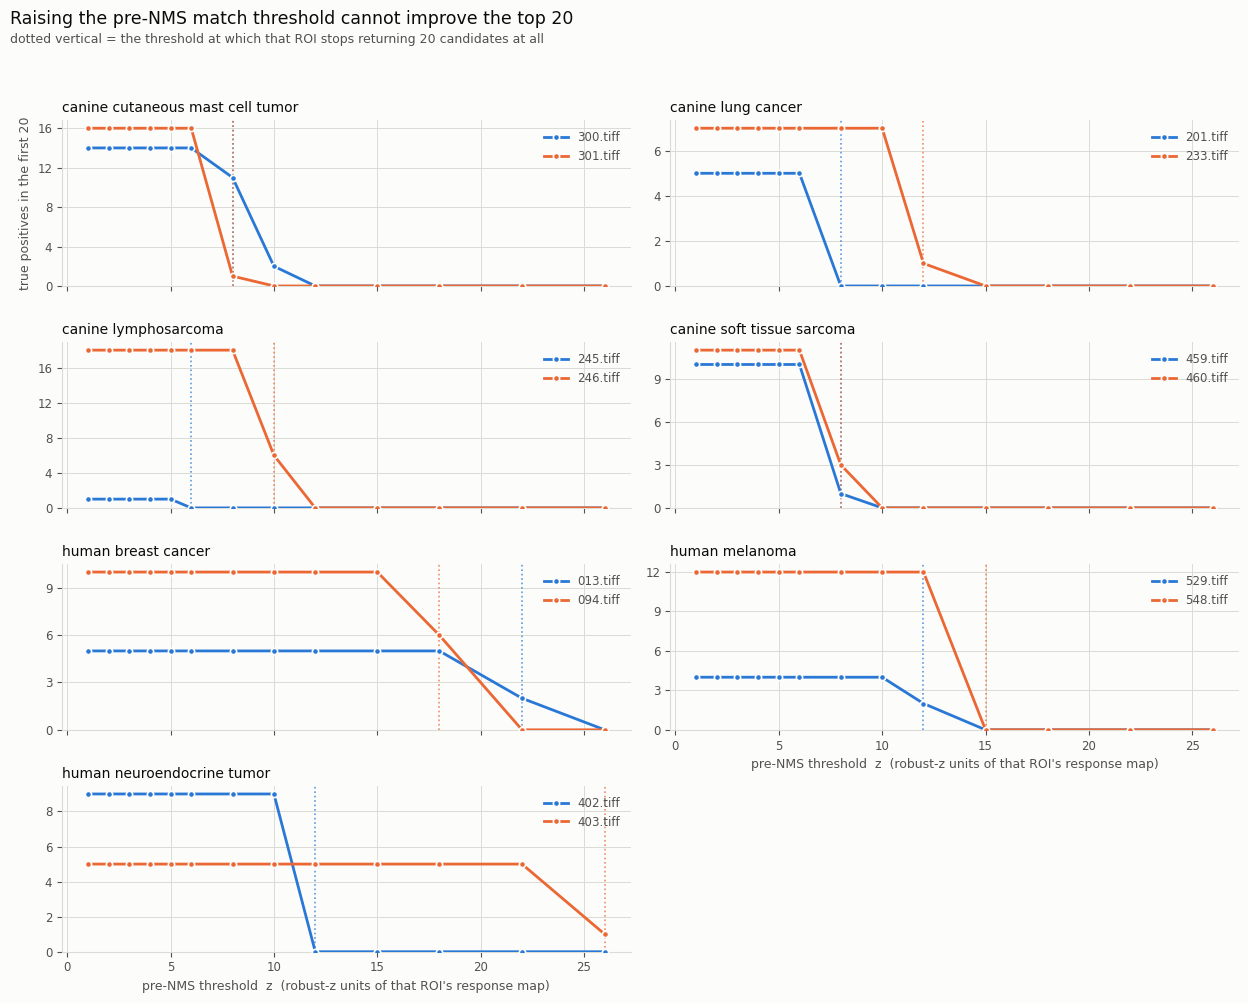

In [14]:
# Palette: the two categorical slots this repo already uses (tm_recall_workload_curve.ipynb,
# "validated as an all-pairs set"). Reused rather than re-picked so figures across the repo
# stay one system; the skill's validator is a node script and node is not installed here.
from matplotlib.ticker import MaxNLocator

SURFACE, INK, INK_2, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#dcdcd6'
SERIES = ['#2a78d6', '#eb6834']

DOMAINS = sorted(ROI['tumor_type'].unique())
ncols = 2
nrows = -(-len(DOMAINS) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12.5, 2.5 * nrows), facecolor=SURFACE,
                         sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, d in zip(axes, DOMAINS):
    ax.set_facecolor(SURFACE)
    rois = sorted(ROI.index[ROI['tumor_type'] == d])
    for i, fn in enumerate(rois):
        sub = CELLS[(CELLS['file_name'] == fn) & (CELLS['z'] >= CURRENT_Z)].sort_values('z')
        ax.plot(sub['z'], sub['tp_at_k'], color=SERIES[i], lw=2, marker='o', ms=4.5,
                mec=SURFACE, mew=1.2, label=fn, zorder=3)
        short = sub[sub['n_retained'] < K]
        if len(short):
            zc = float(short['z'].iloc[0])
            ax.axvline(zc, color=SERIES[i], lw=1.2, ls=':', alpha=0.75, zorder=1)
    ax.set_title(d, color=INK, fontsize=10, loc='left', pad=6)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))  # a TP count has no halves
    ax.grid(True, color=GRID, lw=0.7, zorder=0)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_2, labelsize=8.5)
    ax.legend(frameon=False, fontsize=8.5, labelcolor=INK_2, loc='upper right')

for ax in axes[len(DOMAINS):]:
    ax.set_visible(False)
# sharex hides tick labels on any axis that has another below it, including the hidden
# filler -- so the bottom-most VISIBLE axis in each column has to ask for them back.
bottom = {}
for i in range(len(DOMAINS)):
    bottom[i % ncols] = i
for i in bottom.values():
    axes[i].tick_params(labelbottom=True)
    axes[i].set_xlabel('pre-NMS threshold  z  (robust-z units of that ROI\'s response map)',
                       color=INK_2, fontsize=9)
axes[0].set_ylabel(f'true positives in the first {K}', color=INK_2, fontsize=9)
fig.suptitle(f'Raising the pre-NMS match threshold cannot improve the top {K}',
             color=INK, fontsize=12.5, x=0.005, ha='left', y=0.998)
fig.text(0.005, 0.965, 'dotted vertical = the threshold at which that ROI stops returning '
         f'{K} candidates at all', color=INK_2, fontsize=9, ha='left')
fig.tight_layout(rect=(0, 0, 1, 0.955))
plt.show()

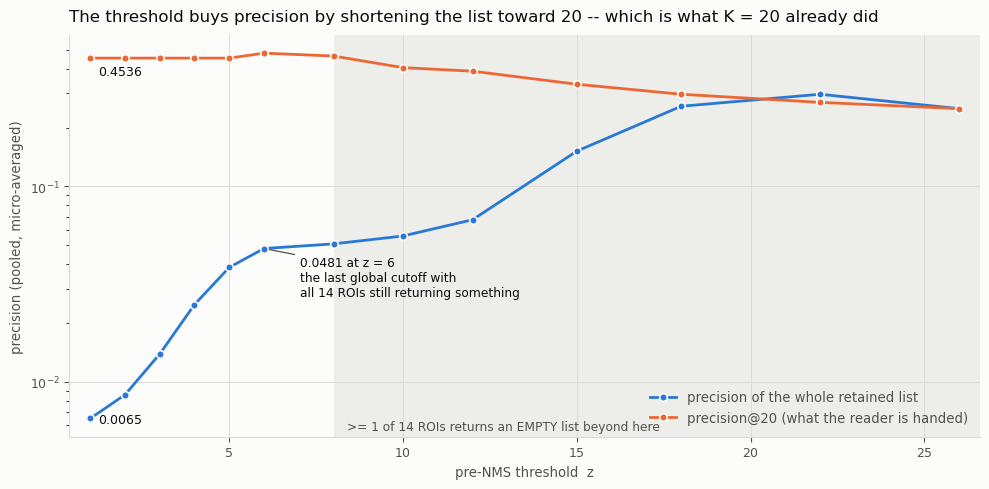

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.0), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
x = T3['z'].to_numpy()

# The honesty band FIRST, behind everything: right of this line the pooled numbers are taken
# over a shrinking subset of the 14 ROIs, because the rest return nothing at all.
z_starve = float(T3.loc[T3['rois_empty'] > 0, 'z'].min())
ax.axvspan(z_starve, x[-1] + 0.6, color=GRID, alpha=0.45, lw=0, zorder=0)
ax.annotate(f'>= 1 of {N_ROI} ROIs returns an EMPTY list beyond here',
            (z_starve + 0.4, 0.0055), color=INK_2, fontsize=8.8, ha='left', va='bottom')

ax.plot(x, T3['precision_full'], color=SERIES[0], lw=2, marker='o', ms=5.5, mec=SURFACE,
        mew=1.2, label='precision of the whole retained list', zorder=3)
ax.plot(x, T3[f'precision_at_{K}'], color=SERIES[1], lw=2, marker='o', ms=5.5, mec=SURFACE,
        mew=1.2, label=f'precision@{K} (what the reader is handed)', zorder=3)
ax.set_yscale('log')
ax.set_xlim(x[0] - 0.6, x[-1] + 0.6)
ax.set_xlabel('pre-NMS threshold  z', color=INK_2, fontsize=9.5)
ax.set_ylabel('precision (pooled, micro-averaged)', color=INK_2, fontsize=9.5)
ax.grid(True, color=GRID, lw=0.7, zorder=1)
ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_color(GRID)
ax.tick_params(colors=INK_2, labelsize=9)
ax.legend(frameon=False, fontsize=9.5, labelcolor=INK_2, loc='lower right')

# Direct labels on the two endpoints of each line only -- never a number on every point.
ax.annotate(f"{T3[f'precision_at_{K}'].iloc[0]:.4f}", (x[0], T3[f'precision_at_{K}'].iloc[0]),
            color=INK, fontsize=9, xytext=(6, -12), textcoords='offset points')
ax.annotate(f"{T3['precision_full'].iloc[0]:.4f}", (x[0], T3['precision_full'].iloc[0]),
            color=INK, fontsize=9, xytext=(6, -3), textcoords='offset points')
z6 = float(T3.loc[T3['rois_empty'] == 0, 'z'].max())
ax.annotate(f"{float(T3.loc[T3['z'] == z6, 'precision_full'].iloc[0]):.4f} at z = {z6:g}\n"
            f'the last global cutoff with\nall {N_ROI} ROIs still returning something',
            (z6, float(T3.loc[T3['z'] == z6, 'precision_full'].iloc[0])), color=INK, fontsize=8.8,
            xytext=(26, -34), textcoords='offset points', ha='left',
            arrowprops=dict(arrowstyle='-', color=INK_2, lw=0.9, shrinkA=2, shrinkB=4))
ax.set_title(f'The threshold buys precision by shortening the list toward {K} -- '
             f'which is what K = {K} already did', color=INK, fontsize=12, loc='left', pad=10)
fig.tight_layout()
plt.show()

## Closing summary

**The gates first.** All 14 ROIs reproduce `results/tm_recall_workload_cells.csv`'s
`seed_index = 0` rows **bit-for-bit** on `seed_ann_id`, `base_size`, `map_median`, `mad_scale`,
the deep pool size and the pool size at `z = 1.0` (6/6 quantities, max absolute difference 0.0).
So this is the committed find-and-suppress pipeline with one knob moved, not a re-implementation
that happens to agree. Every (ROI, threshold) cell then passes the identity check: a genuine
re-extraction and re-NMS at the higher floor returns exactly the points a truncation of the deep
pool returns — 182/182 cells, exact on `cx`, `cy` and `score`, with peak counts of 22 766–60 692
against a 2 000 000 cap so truncation never enters. **596 verification records, 596 passed** —
the final cell asserts that this number matches `len(VERIF)`, so adding a gate without updating
this paragraph fails the run rather than leaving the prose quietly stale.

**And the answer does not depend on which NMS radius "the default" means — though the radius
is not inert.** 7.5 µm (the `FSConfig(nms_radius=None)` default, F5 §7's recommendation) and
5.0 µm (what every script committed since 2026-09-04 actually runs) give **the same `tp_at_20` on
all 14 ROIs**, 127 either way. List *membership* does move, on 1 of 14 ROIs by 1 candidate: on
`245.tiff` the smaller radius admits a secondary peak 20.6 px from a higher-scoring candidate —
inside the 30.2 px radius that suppresses it, outside the 20.1 px one that does not — which
enters at rank 20 and evicts the other list's 20th. That is a **substitution, not a re-ordering**,
and both candidates are false positives, so the count is unchanged. It is the same effect F5
measures as `topk_churn` = 0.0210 Jaccard distance at K = 250 on `tm_score` (1.06 % of membership);
at K = 20 here it is 0.0068, or 0.36 % of membership — the two units differ by roughly 2× and must
not be read as each other. Note this
is a genuinely different knob from the threshold: a threshold can only delete from the tail, while
a radius can insert into the head.

**The answer to the question asked.** Raising the template-matching threshold before NMS has
**no effect whatever** on the number of true positives in the first 20 candidates, for every
threshold that leaves 20 candidates standing. Pooled, that is **127 / 280 true positives,
precision@20 = 0.4536**, identical at the deep floor and at `z = 1, 2, 3, 4, 5`. Across the
higher-threshold grid there are **94 (ROI, threshold) cells whose list is still at least 20 long,
and `tp_at_20` differs from the baseline in 0 of them**. Above `z = 5` the effect is strictly
negative — 126 at `z = 6`, 86 at `z = 8`, 35 at `z = 12`, 1 at `z = 26` — and every fall is, cell
by cell, an ROI whose list has been cut below 20. True positives are lost, never gained.

**One number in Table 1 will look like a counter-example and is not.** Pooled `precision@20`
rises from 0.4536 to 0.4809 at `z = 6`. `245.tiff` has the worst top-20 in the set (1 mitosis,
precision 0.05) and is the first ROI the threshold starves, so at `z = 6` it contributes 2
candidates to the denominator instead of 20. The pooled ratio improved because the worst case
was *censored*. `tp_at_20` fell at the same step.

**The mechanism, and why it is not an artefact of this configuration.** Peak extraction applies
the floor pixel-wise, and NMS is greedy in *descending* score order, so a candidate below the
floor is processed after every candidate above it and can never suppress one. The retained list
at a high floor is therefore a literal prefix of the retained list at a low one — same points,
same scores, same order. Nothing about this depends on the channel, the similarity method, the
template, or the NMS radius; only on NMS being score-ordered, which `midog_utils/nms.py` is by
construction, and on the peak ordering being a global key, which `extract_peaks` is by
construction. (It is the same structure that makes `recall@K` flat below `z_max` in
`tm_recall_workload_curve.ipynb` — seen here from the precision side.)

**One further condition, which this pipeline satisfies silently and a different one would not: the
floor has to be applied to the same quantity that orders NMS and ranks the list.** Here all three
are the `TM_CCOEFF` score, so a deleted candidate is always at the tail. Filter on an *independent*
statistic — chromatin density, size, solidity — and the deletions land in the *middle* of the
`tm_score` order, at which point both halves of the argument fail: pre-NMS, a deleted candidate may
have been the suppressor of a survivor, so its removal un-suppresses a neighbour; post-NMS,
`evaluate.greedy_match` hands the freed annotation to a much deeper detection. `DECISIONS.md` D6(b)
prices the second: on 233.tiff under the a-priori size bound, recall stays at 1.000 while
depth-to-95 % goes **1,328 → 17,341** from deleting 8 % of the pool. So "raising the floor is inert"
is a statement about *this* axis, not a licence to assume any pre-filter is free — which is exactly
why D6(b) requires a prune to be re-matched rather than scored on stored ranks.

**Where a higher threshold does pay, and what it costs.** Precision of the *whole retained list*
rises from **0.0065 at `z = 1.0` to 0.0481 at `z = 6`** — 7.4×, and real. `z = 6` is the highest
global threshold at which all 14 ROIs still return something, and reaching it costs 568 of the
1307 mitoses the list held at `z = 1.0`; `245.tiff`, the worst ROI at every threshold in the grid, goes from 97.8 % of its
mitoses retained to 0 %. Beyond `z = 6` the precision curve keeps climbing to meet precision@20, but only because
ROIs are dropping out: 5 of 14 return nothing at `z = 10`, 11 of 14 at `z = 15`. A threshold is a
blunt way to choose a list length; `K` is a sharp one, because it sets the length directly and
per ROI while a global `z` sets it indirectly and unequally.

**Why no single `z` is a "top-20 setting".** The `z` that leaves exactly 20 candidates ranges
from **5.13 on `245.tiff` to 22.25 on `403.tiff`, a factor of 4.3**. The cutoff that trims
`403.tiff` to 20 leaves `245.tiff` — whose best candidate is at `z = 6.46` — completely empty,
losing all 89 of its mitoses rather than a list's worth of false positives. Robust-z makes the
*search depth* comparable across ROIs; it does not make the *candidate count above a given z*
comparable, because that also depends on how much real structure the ROI contains.

**On precision as the reporting unit.** Precision@20 = 0.4536 pooled, with a per-ROI range of
**0.05 (`245.tiff`) to 0.90 (`246.tiff`)** — an 18× spread that is a far more actionable finding
than anything in the threshold grid, and one this run's single click per ROI cannot separate from
click noise. Precision alone does not close the question either: it is trivially maximised by
returning one candidate, which is exactly what the right-hand end of Table 3 is doing. The honest
two-number summary at a fixed `K` is (precision@K, mitoses found); neither half is interpretable
without the other.

**What this run does not settle.** One click per ROI, as asked. Prior work on this same 14-ROI
set measures roughly a 2× click-to-click spread in reading depth, so the per-ROI precisions above
carry click noise — the threshold-invariance does not, because it is exact per cell. And nothing
here tests a *re-ranking* of the top 20. That is the actual implication: since a floor on the
match score cannot reorder the list, improving the top 20 requires a second axis that is
independent of the match score, not a higher threshold on this one. `DECISIONS.md` D5 and D6
already scope what has and has not been closed on that front.

In [16]:
# The closing summary quotes this count in prose. Prose drifts; an assert does not -- an
# earlier revision of that paragraph said 581, the total as of Gate 2b, and stayed there while
# Gates 3 and 4 pushed it to 596.
N_VERIF_QUOTED_IN_SUMMARY = 596
assert len(VERIF) == N_VERIF_QUOTED_IN_SUMMARY, (
    f'the closing summary quotes {N_VERIF_QUOTED_IN_SUMMARY} verification records; there are '
    f'{len(VERIF)}. Update the prose, or the gate that changed the count.')

print(f'notebook ran in {time.time() - NB_T0:.0f}s')
print(f'  {OUT_CELLS}   {len(CELLS)} rows')
print(f'  {OUT_TOP20}   {len(TOP20)} rows')
print(f'  {OUT_VERIF}   {len(VERIF)} rows, {int(VERIF["passed"].sum())} passed')

notebook ran in 330s
  results/fs_high_threshold_precision_cells.csv   196 rows
  results/fs_high_threshold_precision_top20.csv   280 rows
  results/fs_high_threshold_precision_verification.csv   596 rows, 596 passed
